In [1]:
import os
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, ParameterSampler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import shuffle
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, top_k_accuracy_score, average_precision_score, roc_auc_score

import xgboost as xgb
from xgboost import XGBClassifier
import shap

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import initializers, regularizers
from keras import layers, metrics

# Cache hyperparameter searches and final model specifications
CACHE_PATH_LR_BASE = "../cache/lr_base_model.keras"
CACHE_PATH_LR_SEARCH = "../cache/lr_search_results.joblib"
CACHE_PATH_LR_FINAL = "../cache/lr_final_model.keras"
CACHE_PATH_RF_BASE = "../cache/rf_base_model.joblib"
CACHE_PATH_RF_SEARCH = "../cache/rf_search_results.joblib"
CACHE_PATH_RF_FINAL = "../cache/rf_final_model.joblib"
CACHE_PATH_XGB_BASE = "../cache/xgb_base_model.json"
CACHE_PATH_XGB_SEARCH = "../cache/xgb_search_results.joblib"
CACHE_PATH_XGB_FINAL = "../cache/xgb_final_model.json"
CACHE_PATH_NN_BASE = "../cache/nn_base_model.keras"
CACHE_PATH_NN_SEARCH = "../cache/nn_search_results.joblib"
CACHE_PATH_NN_FINAL = "../cache/nn_final_model.keras"

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

I0000 00:00:1785300449.479769  171630 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785300449.892354  171630 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785300452.627525  171630 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Helper plotting functions

In [2]:
def compute_metrics(y_true_enc, y_proba, num_classes):
    y_pred = np.argmax(y_proba, axis=1)
    y_true_bin = label_binarize(y_true_enc, classes=np.arange(num_classes))

    return {
        'accuracy': accuracy_score(y_true_enc, y_pred),
        'macro_f1': f1_score(y_true_enc, y_pred, average='macro'),
        'roc_auc': roc_auc_score(y_true_enc, y_proba, multi_class='ovr', average='macro'),
        'pr_auc': average_precision_score(y_true_bin, y_proba, average='macro'),
        'top3_accuracy': top_k_accuracy_score(y_true_enc, y_proba, k=3, labels=np.arange(num_classes)),
    }


def print_metrics(model_name, split_name, metrics):
    for metric_name, value in metrics.items():
        print(f'{model_name} {split_name} {metric_name}: {value:.4f}')


def plot_accuracy(history, ax=None, title=""):
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(history.history['accuracy'], color='black', label='train')
    ax.plot(history.history['val_accuracy'], color='red', label='val')
    ax.set_xlabel('epoch')
    ax.set_ylabel('accuracy')
    ax.set_title(f'Train vs. Validation Accuracy\n{title}')
    ax.legend()
    if ax is None:
        plt.show()


def plot_loss(history, ax=None, title=""):
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(history.history['loss'], color='black', label='train')
    ax.plot(history.history['val_loss'], color='red', label='val')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.set_title(f'Train vs. Validation Loss\n{title}')
    ax.legend()
    if ax is None:
        plt.show()

# Load and split data

In [3]:
# Load data
features = pd.read_csv('../data/raw/fma_metadata/features.csv', index_col=0, header=[0, 1, 2])
tracks = pd.read_csv('../data/raw/fma_metadata/tracks.csv', index_col=0, header=[0, 1])

# Extract genre labels and reindex to match features
genre_labels = tracks[('track', 'genre_top')]
genre_labels = genre_labels.reindex(features.index)

# Drop tracks missing top-level genre (56,976 tracks)
genre_labels = genre_labels.dropna()

# Drop genres with fewer than 500 observations (5 genres removed)
min_count = 500
valid_genres = genre_labels.value_counts()[lambda x: x >= min_count].index
genre_labels = genre_labels[genre_labels.isin(valid_genres)]
features = features.loc[genre_labels.index]
# 48,672 tracks across 11 genres remaining

# Train/val/test split (60/20/20, stratified)
train_ids, test_ids = train_test_split(
    genre_labels.index, test_size=0.2, stratify=genre_labels, random_state=1234
)
train_ids, val_ids = train_test_split(
    train_ids, test_size=0.25, stratify=genre_labels.loc[train_ids], random_state=1234
)

X_train = features.loc[train_ids]
X_val = features.loc[val_ids]
X_test = features.loc[test_ids]

Y_train = genre_labels.loc[train_ids]
Y_val = genre_labels.loc[val_ids]
Y_test = genre_labels.loc[test_ids]

# Drop near-constant columns

In [4]:
selector = VarianceThreshold(threshold=1e-8)
selector.fit(X_train)

cols_to_drop = X_train.columns[~selector.get_support()]
X_train = X_train.drop(columns=cols_to_drop)
X_val = X_val.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

# Standardize features and encode labels

In [5]:
scaler = StandardScaler().set_output(transform="pandas")
le = LabelEncoder()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Y_train_enc = le.fit_transform(Y_train)
Y_val_enc = le.transform(Y_val)
Y_test_enc = le.transform(Y_test)

# Calculate class weights
classes = np.unique(Y_train_enc)
balanced_class_weight = dict(zip(classes, compute_class_weight('balanced', classes=classes, y=Y_train_enc)))

# Shuffle data.
X_train_scaled, Y_train_enc = shuffle(X_train_scaled, Y_train_enc, random_state=1234)
X_train_scaled = X_train_scaled.reset_index(drop=True)

# Simple Dummy Classifier Baseline
Always predict the most common class (Rock).

In [6]:
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=1234)
dummy_clf.fit(X_train_scaled, Y_train_enc)

dummy_train_pred = dummy_clf.predict(X_train_scaled)
dummy_val_pred = dummy_clf.predict(X_val_scaled)

dummy_train_accuracy = accuracy_score(Y_train_enc, dummy_train_pred)
dummy_train_f1 = f1_score(Y_train_enc, dummy_train_pred, average='macro')

dummy_val_accuracy = accuracy_score(Y_val_enc, dummy_val_pred)
dummy_val_f1 = f1_score(Y_val_enc, dummy_val_pred, average='macro')

print(f'Dummy Baseline Train Accuracy: {dummy_train_accuracy:.4f}')
print(f'Dummy Baseline Train Macro-F1 Score: {dummy_train_f1:.4f}')
print(f'Dummy Baseline Validation Accuracy: {dummy_val_accuracy:.4f}')
print(f'Dummy Baseline Validation Macro-F1 Score: {dummy_val_f1:.4f}')

dummy_test_pred = dummy_clf.predict(X_test_scaled)
dummy_test_accuracy = accuracy_score(Y_test_enc, dummy_test_pred)
dummy_test_f1 = f1_score(Y_test_enc, dummy_test_pred, average='macro')

print(f'Dummy Baseline Test Accuracy: {dummy_test_accuracy:.4f}')
print(f'Dummy Baseline Test Macro-F1 Score: {dummy_test_f1:.4f}')

Dummy Baseline Train Accuracy: 0.2914
Dummy Baseline Train Macro-F1 Score: 0.0410
Dummy Baseline Validation Accuracy: 0.2913
Dummy Baseline Validation Macro-F1 Score: 0.0410
Dummy Baseline Test Accuracy: 0.2914
Dummy Baseline Test Macro-F1 Score: 0.0410


The dummy baseline (always predicting Rock, the majority class) sets the floor: accuracy lands around Rock's ~29% share of the data in all three splits, since stratification preserves that ratio. Macro-F1 is far more damning: since it never predicts any of the other 10 genres, it scores zero recall and F1 on all of them, pulling macro-F1 down to just 0.0410, identical across train, val, and test, confirming the stratified split preserves Rock's proportion consistently across all three sets.

# Logistic Regression
Implement a logistic regression model with L2 regularization.

In [7]:
def build_lr_model(num_features, lr=0.001, l2=0.001):
    """Return a simple logistic regression model using the Keras Functional API."""
    # Clear session and set a random seed for consistent behavior.
    tf.keras.backend.clear_session()
    tf.random.set_seed(1234)
    np.random.seed(1234)

    # Use Keras Functional API to build a logistic regression
    inputs = tf.keras.Input(shape=(num_features,), name='Input')
    outputs = tf.keras.layers.Dense(units=len(le.classes_), activation='softmax', kernel_regularizer=regularizers.l2(l2))(inputs)

    model = tf.keras.Model(inputs, outputs)

    # Use Categorical Crossentropy as our loss and the Adam optimizer.
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )

    return model

In [8]:
if os.path.exists(CACHE_PATH_LR_BASE):
    lr_baseline = keras.models.load_model(CACHE_PATH_LR_BASE)
    print('Loaded cached baseline Logistic Regression model')
else:
    lr_baseline = build_lr_model(num_features=X_train_scaled.shape[1])

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
    )

    lr_hist = lr_baseline.fit(X_train_scaled, Y_train_enc,
                 validation_data=(X_val_scaled, Y_val_enc),
                 epochs=200, 
                 batch_size=32,
                 callbacks=[early_stop],
                 verbose=0)

    plot_accuracy(lr_hist)
    plot_loss(lr_hist)

    lr_baseline.save(CACHE_PATH_LR_BASE)
    print('Trained and cached baseline Logistic Regression model')

lr_train_proba = lr_baseline.predict(X_train_scaled, verbose=0)
lr_val_proba = lr_baseline.predict(X_val_scaled, verbose=0)

lr_train_metrics = compute_metrics(Y_train_enc, lr_train_proba, len(le.classes_))
lr_val_metrics = compute_metrics(Y_val_enc, lr_val_proba, len(le.classes_))

print_metrics('Baseline LR', 'Train', lr_train_metrics)
print_metrics('Baseline LR', 'Validation', lr_val_metrics)


W0000 00:00:1785300463.732611  171630 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1785300463.736369  171630 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1785300463.927939  171630 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9217 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:01:00.0, compute capability: 12.0a


Loaded cached baseline Logistic Regression model
Baseline LR Train accuracy: 0.6762
Baseline LR Train macro_f1: 0.6028
Baseline LR Train roc_auc: 0.9255
Baseline LR Train pr_auc: 0.6509
Baseline LR Train top3_accuracy: 0.8981
Baseline LR Validation accuracy: 0.6511
Baseline LR Validation macro_f1: 0.5606
Baseline LR Validation roc_auc: 0.9070
Baseline LR Validation pr_auc: 0.5911
Baseline LR Validation top3_accuracy: 0.8808


Baseline logistic regression (L2 regularization, no class weighting) reaches 67% train / 65% validation accuracy and 0.603/0.561 macro F-1.
Modest train-val gap suggests mild overfitting.

### Hyperparameter tuning

In [9]:
l2_values = [0.0001, 0.001, 0.01, 0.1]
balanced_options = [False, True]

if os.path.exists(CACHE_PATH_LR_SEARCH):
    lr_results_df = joblib.load(CACHE_PATH_LR_SEARCH)
    print("Loaded cached LR search results.")
else:
    results_lr = []

    for l2_value, use_balanced in product(l2_values, balanced_options):
        print(f'Candidate: l2={l2_value}, balanced={use_balanced}')

        model = build_lr_model(num_features=X_train_scaled.shape[1], l2=l2_value)
        class_weight = balanced_class_weight if use_balanced else None

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
        )

        model.fit(
            X_train_scaled, Y_train_enc,
            validation_data=(X_val_scaled, Y_val_enc),
            epochs=200,
            batch_size=32,
            callbacks=[early_stop],
            class_weight=class_weight,
            verbose=0,
        )

        train_pred = np.argmax(model.predict(X_train_scaled, verbose=0), axis=1)
        val_pred = np.argmax(model.predict(X_val_scaled, verbose=0), axis=1)

        train_accuracy = accuracy_score(Y_train_enc, train_pred)
        val_accuracy = accuracy_score(Y_val_enc, val_pred)

        results_lr.append({
            'l2': l2_value,
            'balanced': use_balanced,
            'train_accuracy': train_accuracy,
            'val_accuracy': val_accuracy,
            'val_macro_f1': f1_score(Y_val_enc, val_pred, average='macro'),
            'train_val_gap': train_accuracy - val_accuracy,
        })

    lr_results_df = pd.DataFrame(results_lr).sort_values('val_macro_f1', ascending=False)
    joblib.dump(lr_results_df, CACHE_PATH_LR_SEARCH)

print(lr_results_df)

Loaded cached LR search results.
       l2  balanced  train_accuracy  val_accuracy  val_macro_f1  train_val_gap
0  0.0001     False        0.679132      0.651361      0.563835       0.027770
2  0.0010     False        0.675536      0.652491      0.561717       0.023045
4  0.0100     False        0.653483      0.642732      0.520496       0.010750
3  0.0010      True        0.600815      0.567745      0.515496       0.033070
1  0.0001      True        0.600712      0.566718      0.513521       0.033994
5  0.0100      True        0.576330      0.560041      0.504387       0.016289
7  0.1000      True        0.527087      0.525424      0.464676       0.001663
6  0.1000     False        0.605061      0.599795      0.436368       0.005267


Grid search over l2 regularization strength (0.0001–0.1) and class weighting shows balanced=True consistently hurts macro-F1 at every l2 value except the strongest (0.1), where both configs perform poorly enough that the difference is likely just noise. Weaker regularization performs best, and val macro-F1 falls monotonically as l2 increases, from 0.564 at l2=0.0001 down to 0.436 at l2=0.1 (unbalanced), suggesting the true optimum sits at or below the lightest setting tested. The best candidate (l2=0.0001, balanced=False) reaches val accuracy 65.1% and val macro-F1 0.564, with l2=0.001 essentially tied (0.562), and a train-val gap of 2.8%.

### Implement Best Logistic Regression Model

In [10]:
best_params_lr = lr_results_df.iloc[0][['l2', 'balanced']].to_dict()

if os.path.exists(CACHE_PATH_LR_FINAL):
    best_lr = keras.models.load_model(CACHE_PATH_LR_FINAL)
    print('Loaded cached Logistic Regression model')
else:
    use_balanced = best_params_lr.pop('balanced')

    best_lr = build_lr_model(num_features=X_train_scaled.shape[1], **best_params_lr)

    class_weight = balanced_class_weight if use_balanced else None

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
    )

    best_lr.fit(
        X_train_scaled, Y_train_enc,
        validation_data=(X_val_scaled, Y_val_enc),
        epochs=200,
        batch_size=32,
        callbacks=[early_stop],
        class_weight=class_weight,
        verbose=0,
    )

    best_lr.save(CACHE_PATH_LR_FINAL)
    print('Trained and cached final Logistic Regression model')

lr_test_proba = best_lr.predict(X_test_scaled, verbose=0)
lr_test_pred = np.argmax(lr_test_proba, axis=1)

lr_test_metrics = compute_metrics(Y_test_enc, lr_test_proba, len(le.classes_))

print_metrics('Best LR', 'Test', lr_test_metrics)


Loaded cached Logistic Regression model
Best LR Test accuracy: 0.6517
Best LR Test macro_f1: 0.5491
Best LR Test roc_auc: 0.9051
Best LR Test pr_auc: 0.5880
Best LR Test top3_accuracy: 0.8795


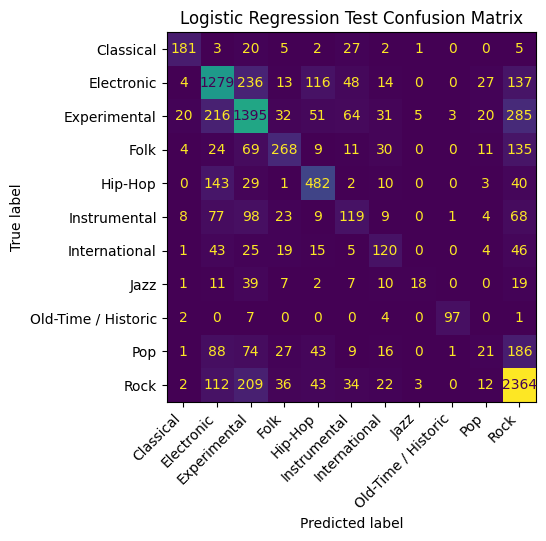

                     precision    recall  f1-score   support

          Classical       0.81      0.74      0.77       246
         Electronic       0.64      0.68      0.66      1874
       Experimental       0.63      0.66      0.65      2122
               Folk       0.62      0.48      0.54       561
            Hip-Hop       0.62      0.68      0.65       710
       Instrumental       0.37      0.29      0.32       416
      International       0.45      0.43      0.44       278
               Jazz       0.67      0.16      0.26       114
Old-Time / Historic       0.95      0.87      0.91       111
                Pop       0.21      0.05      0.07       466
               Rock       0.72      0.83      0.77      2837

           accuracy                           0.65      9735
          macro avg       0.61      0.53      0.55      9735
       weighted avg       0.63      0.65      0.63      9735



In [11]:
# Plot confusion matrix
cm_lr = confusion_matrix(Y_test_enc, lr_test_pred)

fig, ax = plt.subplots()
disp = ConfusionMatrixDisplay(cm_lr, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False)
ax.grid(False)
plt.title("Logistic Regression Test Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.show()

print(classification_report(Y_test_enc, lr_test_pred, target_names=le.classes_))

Test performance (65.2% accuracy, 0.549 macro-F1) essentially matches validation (65.1% accuracy, 0.564 macro-F1), about 1.5pp lower on macro-F1, confirming the l2/balanced choice generalizes and wasn't overfit to the 8-candidate search.

Top-3 accuracy reaches 88.0%, meaning the correct genre is in the model's top three guesses more than four out of five times, even though only two-thirds of tracks get the single best guess right.

Old-Time/Historic (97/111, 87% recall) and Classical (181/246, 74% recall) remain the best-separated classes, and Rock stays strong (2363/2837, 83% recall). Pop and Jazz are the clear weak points: Pop is correctly identified only 21 of 466 times (5% recall), with 186 of those tracks misclassified as Rock alone, and Jazz's largest error bucket (39, into Experimental) exceeds its own correct count (18). Instrumental (119/416, 29% recall) and International (120/278, 43% recall) round out the weakest classes, consistent with smaller, more acoustically ambiguous genres being the hardest to separate from the larger ones.

# Random Forest Classifier

In [12]:
if os.path.exists(CACHE_PATH_RF_BASE):
    rf_clf = joblib.load(CACHE_PATH_RF_BASE)
    print('Loaded cached baseline Random Forest model')
else:
    rf_clf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=1234)
    rf_clf.fit(X_train_scaled, Y_train_enc)
    joblib.dump(rf_clf, CACHE_PATH_RF_BASE)
    print('Trained and cached baseline Random Forest model')

rf_train_proba = rf_clf.predict_proba(X_train_scaled)
rf_val_proba = rf_clf.predict_proba(X_val_scaled)

rf_train_metrics = compute_metrics(Y_train_enc, rf_train_proba, len(le.classes_))
rf_val_metrics = compute_metrics(Y_val_enc, rf_val_proba, len(le.classes_))

print_metrics('Baseline Random Forest', 'Train', rf_train_metrics)
print_metrics('Baseline Random Forest', 'Validation', rf_val_metrics)

Loaded cached baseline Random Forest model


/home/vlad/github/datasci207_final_project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/home/vlad/github/datasci207_final_project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Baseline Random Forest Train accuracy: 0.9988
Baseline Random Forest Train macro_f1: 0.9988
Baseline Random Forest Train roc_auc: 1.0000
Baseline Random Forest Train pr_auc: 1.0000
Baseline Random Forest Train top3_accuracy: 1.0000
Baseline Random Forest Validation accuracy: 0.6392
Baseline Random Forest Validation macro_f1: 0.5002
Baseline Random Forest Validation roc_auc: 0.9025
Baseline Random Forest Validation pr_auc: 0.6061
Baseline Random Forest Validation top3_accuracy: 0.8608


The unconstrained baseline (n_estimators=300, no depth cap) essentially memorizes the training set (0.999 train accuracy/F1) while validation lands at 64% accuracy, 0.50 macro-F1, a severe ~36-50pp gap. This is expected for unregularized random forests on high-dimensional tabular data and motivates the depth/leaf-size search below.

### Hyperparameter tuning

In [13]:
param_dist = {
    'max_depth': [8, 12, 16, 20, None],
    'max_features': ['sqrt', 'log2', 0.3],
    'min_samples_leaf': [1, 2, 5, 10],
    'class_weight': [None, 'balanced'],
}
param_list_rf = list(ParameterSampler(param_dist, n_iter=20, random_state=1234))

if os.path.exists(CACHE_PATH_RF_SEARCH):
    rf_results_df = joblib.load(CACHE_PATH_RF_SEARCH)
    print("Loaded cached RF search results.")
else:
    results_rf = []

    for params in param_list_rf:
        model = RandomForestClassifier(n_jobs=-1, random_state=1234, **params)
        model.fit(X_train_scaled, Y_train_enc)

        train_pred = model.predict(X_train_scaled)
        val_pred = model.predict(X_val_scaled)

        results_rf.append({
            **params,
            'train_accuracy': accuracy_score(Y_train_enc, train_pred),
            'val_accuracy': accuracy_score(Y_val_enc, val_pred),
            'val_macro_f1': f1_score(Y_val_enc, val_pred, average='macro'),
            'train_val_gap': accuracy_score(Y_train_enc, train_pred) - accuracy_score(Y_val_enc, val_pred)
        })

    rf_results_df = pd.DataFrame(results_rf).sort_values('val_macro_f1', ascending=False)
    joblib.dump(rf_results_df, CACHE_PATH_RF_SEARCH) # Cache results
print(rf_results_df.head(10))

Loaded cached RF search results.
    min_samples_leaf max_features  max_depth class_weight  train_accuracy  \
4                  1          0.3       20.0     balanced        0.980994   
18                 2         sqrt       20.0     balanced        0.966475   
14                 2         log2       16.0     balanced        0.936100   
9                  5         sqrt       20.0     balanced        0.871242   
5                  5         sqrt       16.0     balanced        0.852681   
7                 10          0.3       20.0     balanced        0.783713   
19                 5         log2        NaN     balanced        0.864667   
13                 1          0.3       16.0         None        0.980241   
3                 10         sqrt       16.0     balanced        0.768406   
2                  1         sqrt        NaN         None        0.998767   

    val_accuracy  val_macro_f1  train_val_gap  
4       0.617771      0.560988       0.363224  
18      0.612635      0

Even after random search over max_depth, max_features, min_samples_leaf, and class_weight, every top-10 candidate still shows a large train-val gap (20–37pp), suggesting RF has a harder time generalizing on this feature set regardless of regularization, possibly because heavy feature redundancy (many correlated statistical aggregates per coefficient) undermines the benefit of RF's random per-split feature subsampling. Rather than taking the top val_macro_f1 row outright (which has a 36pp gap), the final config (min_samples_leaf=10, max_features=0.3, max_depth=20, class_weight='balanced') was chosen for a better gap/performance tradeoff (21pp gap, 0.519 macro-F1).

### Implement best Random Forest model

In [14]:
# index 7: gap-aware pick over top val_macro_f1, see analysis above
best_params_rf = rf_results_df.loc[7][[
    'min_samples_leaf', 'max_features', 'max_depth', 'class_weight'
]].to_dict()

# Convert max_depth to int
if pd.isna(best_params_rf['max_depth']):
    best_params_rf['max_depth'] = None
else:
    best_params_rf['max_depth'] = int(best_params_rf['max_depth'])

if os.path.exists(CACHE_PATH_RF_FINAL):
    best_rf = joblib.load(CACHE_PATH_RF_FINAL)
    print('Loaded cached Random Forest model')
else:
    best_rf = RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=1234, **best_params_rf)
    best_rf.fit(X_train_scaled, Y_train_enc)
    joblib.dump(best_rf, CACHE_PATH_RF_FINAL)
    print('Trained and cached final Random Forest model')

rf_test_proba = best_rf.predict_proba(X_test_scaled)
rf_test_pred = np.argmax(rf_test_proba, axis=1)

rf_test_metrics = compute_metrics(Y_test_enc, rf_test_proba, len(le.classes_))

print_metrics('Best Random Forest', 'Test', rf_test_metrics)

Loaded cached Random Forest model


/home/vlad/github/datasci207_final_project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Best Random Forest Test accuracy: 0.5926
Best Random Forest Test macro_f1: 0.5270
Best Random Forest Test roc_auc: 0.8958
Best Random Forest Test pr_auc: 0.5820
Best Random Forest Test top3_accuracy: 0.8219


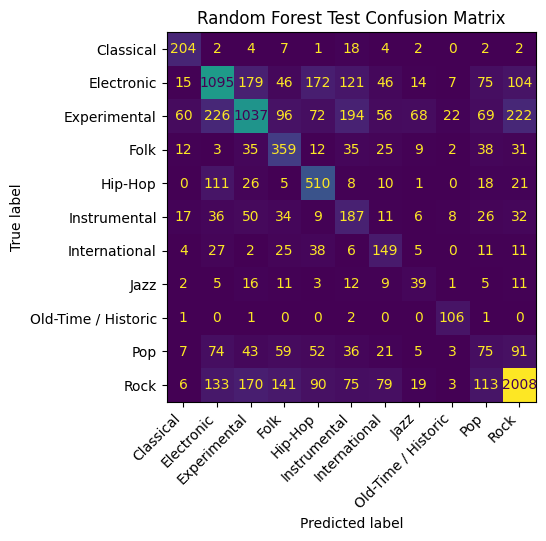

                     precision    recall  f1-score   support

          Classical       0.62      0.83      0.71       246
         Electronic       0.64      0.58      0.61      1874
       Experimental       0.66      0.49      0.56      2122
               Folk       0.46      0.64      0.53       561
            Hip-Hop       0.53      0.72      0.61       710
       Instrumental       0.27      0.45      0.34       416
      International       0.36      0.54      0.43       278
               Jazz       0.23      0.34      0.28       114
Old-Time / Historic       0.70      0.95      0.81       111
                Pop       0.17      0.16      0.17       466
               Rock       0.79      0.71      0.75      2837

           accuracy                           0.59      9735
          macro avg       0.49      0.58      0.53      9735
       weighted avg       0.62      0.59      0.60      9735



In [15]:
# Plot confusion matrix
cm_rf = confusion_matrix(Y_test_enc, rf_test_pred)

fig, ax = plt.subplots()
disp = ConfusionMatrixDisplay(cm_rf, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False)
ax.grid(False)
plt.title("Random Forest Test Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.show()

print(classification_report(Y_test_enc, rf_test_pred, target_names=le.classes_))

RF test performance (59% accuracy, 0.53 macro-F1) comes in below the logistic regression baseline despite hyperparameter tuning. This is a somewhat counterintuitive result tied to the feature redundancy noted above rather than a tuning failure. The final model uses n_estimators=500 while the hyperparameter search itself only ever used RF's default of 100 trees (n_estimators wasn't part of param_dist), so the "best" config was selected at 100 trees and then scaled up to save search time.

Top-3 accuracy (82.2%) is also the lowest of the four models, consistent with RF's weaker overall performance on this feature set.

Compared to logistic regression, errors are more spread out across nearly every genre rather than concentrated in one or two weak classes. Even large, well-supported genres take a bigger hit here, with Rock recall dropping to 71% (2008/2837) versus logistic regression's 83%, and Electronic recall falling to 58% (1095/1874) versus 68%. Pop and Jazz remain weak (16% and 34% recall respectively), but unlike logistic regression, RF's errors aren't concentrated into one dominant confusion target per class. Electronic, Experimental, Hip-Hop, and Rock all draw meaningful misclassifications from most other genres, consistent with the model's lower overall macro-F1 despite comparable or occasionally better performance on individual rare classes.

# XGBoost

In [16]:
# implement xgboost model
if os.path.exists(CACHE_PATH_XGB_BASE):
    xgb_baseline = joblib.load(CACHE_PATH_XGB_BASE)
    print('Loaded cached baseline XGBoost model')
else:
    xgb_baseline = XGBClassifier(
        objective='multi:softprob',
        num_class=len(le.classes_),
        eval_metric='mlogloss',
        early_stopping_rounds=20,
        n_estimators=500,
        learning_rate=0.1,
        n_jobs=-1,
        random_state=1234,
        device='cuda'
    )

    xgb_baseline.fit(
        X_train_scaled, Y_train_enc,
        eval_set=[(X_val_scaled, Y_val_enc)],
        verbose=False,
    )
    joblib.dump(xgb_baseline, CACHE_PATH_XGB_BASE)
    print('Trained and cached baseline XGBoost model')

print('Best iteration:', xgb_baseline.best_iteration)

xgb_train_proba = xgb_baseline.predict_proba(X_train_scaled)
xgb_val_proba = xgb_baseline.predict_proba(X_val_scaled)

xgb_train_metrics = compute_metrics(Y_train_enc, xgb_train_proba, len(le.classes_))
xgb_val_metrics = compute_metrics(Y_val_enc, xgb_val_proba, len(le.classes_))

print_metrics('Baseline XGBoost', 'Train', xgb_train_metrics)
print_metrics('Baseline XGBoost', 'Validation', xgb_val_metrics)

Loaded cached baseline XGBoost model
Best iteration: 191


/home/vlad/github/datasci207_final_project/.venv/lib/python3.12/site-packages/xgboost/core.py:553: UserWarning: [21:47:50] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Baseline XGBoost Train accuracy: 0.9821
Baseline XGBoost Train macro_f1: 0.9880
Baseline XGBoost Train roc_auc: 0.9997
Baseline XGBoost Train pr_auc: 0.9989
Baseline XGBoost Train top3_accuracy: 0.9998
Baseline XGBoost Validation accuracy: 0.6860
Baseline XGBoost Validation macro_f1: 0.5866
Baseline XGBoost Validation roc_auc: 0.9257
Baseline XGBoost Validation pr_auc: 0.6577
Baseline XGBoost Validation top3_accuracy: 0.8961


The default-hyperparameter XGBoost model already outperforms both tuned LR and tuned RF on validation (69% accuracy, 0.59 macro-F1) at best_iteration=191, consistent with gradient boosting's usual edge on tabular data. It's still overfit (98% train vs 69% val), leaving clear room for the regularization-focused search below.

### Hyperparameter tuning

In [17]:
param_dist_xgb = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 6, 8],
    'min_child_weight': [1, 3, 5, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1.0],
    'reg_lambda': [0.1, 1.0, 5.0, 10.0],
    'gamma': [0, 0.1, 0.5, 1.0],
    'balanced': [False, True],
}

param_list_xgb = list(ParameterSampler(param_dist_xgb, n_iter=100, random_state=1234))

if os.path.exists(CACHE_PATH_XGB_SEARCH):
    xgb_results_df = joblib.load(CACHE_PATH_XGB_SEARCH)
    print("Loaded cached XGB search results.")
else:
    results_xgb = []

    for i, raw_params in enumerate(param_list_xgb):
        params = dict(raw_params)
        use_balanced = params.pop('balanced')
        sample_weights = compute_sample_weight('balanced', Y_train_enc) if use_balanced else None

        print(f'Candidate {i+1}/{len(param_list_xgb)}: balanced={use_balanced}, {params}')
        model = XGBClassifier(
            objective='multi:softprob',
            num_class=len(le.classes_),
            eval_metric='mlogloss',
            early_stopping_rounds=20,
            n_estimators=2000,
            n_jobs=-1,
            random_state=1234,
            device='cuda',
            **params,
        )
        model.fit(
            X_train_scaled, Y_train_enc,
            sample_weight=sample_weights,
            eval_set=[(X_val_scaled, Y_val_enc)],
            verbose=False,
        )
        train_pred = model.predict(X_train_scaled)
        val_pred = model.predict(X_val_scaled)

        results_xgb.append({
            **params,
            'balanced': use_balanced,
            'best_iteration': model.best_iteration,
            'train_accuracy': accuracy_score(Y_train_enc, train_pred),
            'val_accuracy': accuracy_score(Y_val_enc, val_pred),
            'val_macro_f1': f1_score(Y_val_enc, val_pred, average='macro'),
            'train_val_gap': accuracy_score(Y_train_enc, train_pred) - accuracy_score(Y_val_enc, val_pred),
        })

    xgb_results_df = pd.DataFrame(results_xgb).sort_values('val_macro_f1', ascending=False)
    joblib.dump(xgb_results_df, CACHE_PATH_XGB_SEARCH)
print(xgb_results_df.head(20))

Loaded cached XGB search results.
    subsample  reg_lambda  reg_alpha  min_child_weight  max_depth  \
5         0.8         5.0       0.00                10          6   
58        0.8        10.0       1.00                 1          4   
56        0.6         0.1       1.00                 1          4   
20        0.6         5.0       1.00                10          8   
30        0.8         5.0       0.01                 5          3   
84        0.6        10.0       0.00                 5          3   
25        0.8        10.0       0.10                 5          6   
48        0.8        10.0       0.01                 3          3   
89        0.6         5.0       0.10                 1          3   
54        0.6         5.0       0.00                 5          4   
64        0.6         0.1       0.01                10          6   
93        0.8         0.1       0.01                 5          3   
28        0.8         0.1       0.00                 1          4   


Random search (100 candidates) over learning rate, depth, subsampling, and L1/L2 regularization was run in two passes. An initial n_estimators=1000 cap left 35 candidates truncated by early-stopping's ceiling rather than genuine convergence, so the cap was raised to 2000 to get trustworthy stopping points — though even at 2000, 7 of the top 20 candidates still finish at or near the new ceiling (≥1990 rounds), so some stopping points remain unconfirmed. The top candidate (max_depth=6, learning_rate=0.05, reg_lambda=5, reg_alpha=0, min_child_weight=10, balanced=True) converges cleanly at iteration 985, well under the cap, with val macro-F1 of 0.639. It's only marginally ahead of the #2 candidate (max_depth=4, learning_rate=0.1, reg_lambda=10, reg_alpha=1, balanced=True; iteration 898, F1=0.638) — a gap of 0.001, within likely validation-split noise, so this should be treated as a near-tie pending a cross-validated check rather than a clear winner.

### Implement Best XGBoost Model

In [18]:
best_params_xgb = xgb_results_df.iloc[0][[
    'subsample', 'reg_lambda', 'reg_alpha', 'min_child_weight',
    'max_depth', 'learning_rate', 'gamma', 'colsample_bytree', 'balanced',
]].to_dict()

use_balanced = best_params_xgb.pop('balanced')
best_params_xgb['max_depth'] = int(best_params_xgb['max_depth'])
best_params_xgb['min_child_weight'] = int(best_params_xgb['min_child_weight'])

best_n_estimators = int(xgb_results_df.iloc[0]['best_iteration']) + 1

if os.path.exists(CACHE_PATH_XGB_FINAL):
    best_xgb = XGBClassifier()
    best_xgb.load_model(CACHE_PATH_XGB_FINAL)
    print('Loaded cached XGBoost model')
else:
    sample_weight = compute_sample_weight('balanced', Y_train_enc) if use_balanced else None

    best_xgb = XGBClassifier(
        objective='multi:softprob',
        num_class=len(le.classes_),
        eval_metric='mlogloss',
        n_estimators=best_n_estimators,
        n_jobs=-1,
        random_state=1234,
        device='cuda',
        tree_method='hist',
        **best_params_xgb,
    )
    best_xgb.fit(X_train_scaled, Y_train_enc, sample_weight=sample_weight)
    best_xgb.save_model(CACHE_PATH_XGB_FINAL)
    print('Trained and cached final XGBoost model')

xgb_test_proba = best_xgb.predict_proba(X_test_scaled)
xgb_test_pred = np.argmax(xgb_test_proba, axis=1)

xgb_test_metrics = compute_metrics(Y_test_enc, xgb_test_proba, len(le.classes_))

print_metrics('Best XGBoost', 'Test', xgb_test_metrics)

Loaded cached XGBoost model
Best XGBoost Test accuracy: 0.7093
Best XGBoost Test macro_f1: 0.6319
Best XGBoost Test roc_auc: 0.9355
Best XGBoost Test pr_auc: 0.6793
Best XGBoost Test top3_accuracy: 0.9068


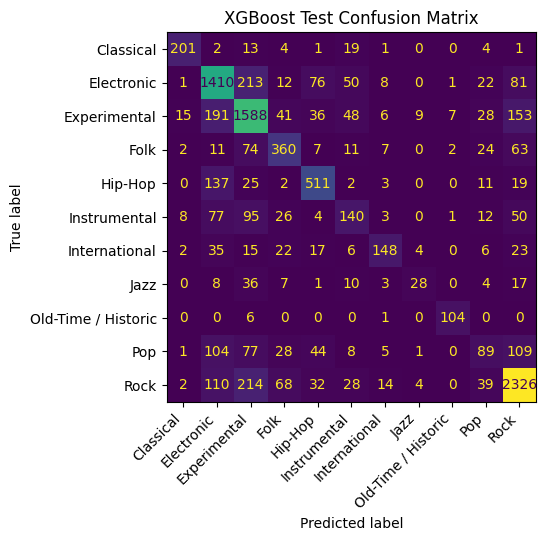

                     precision    recall  f1-score   support

          Classical       0.87      0.82      0.84       246
         Electronic       0.68      0.75      0.71      1874
       Experimental       0.67      0.75      0.71      2122
               Folk       0.63      0.64      0.64       561
            Hip-Hop       0.70      0.72      0.71       710
       Instrumental       0.43      0.34      0.38       416
      International       0.74      0.53      0.62       278
               Jazz       0.61      0.25      0.35       114
Old-Time / Historic       0.90      0.94      0.92       111
                Pop       0.37      0.19      0.25       466
               Rock       0.82      0.82      0.82      2837

           accuracy                           0.71      9735
          macro avg       0.68      0.61      0.63      9735
       weighted avg       0.70      0.71      0.70      9735



In [19]:
# Plot confusion matrix
cm_xgb = confusion_matrix(Y_test_enc, xgb_test_pred)

fig, ax = plt.subplots()
disp = ConfusionMatrixDisplay(cm_xgb, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False)
ax.grid(False)
plt.title("XGBoost Test Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.show()

print(classification_report(Y_test_enc, xgb_test_pred, target_names=le.classes_))

XGBoost's test performance (70.93% accuracy, 0.632 macro-F1) is the best of the three models thus far, and closely tracks its validation numbers (macro-F1 down only 0.7pp from val's 0.639), indicating the 100-candidate search didn't overfit to the validation set.

Top-3 accuracy reaches 90.7%, the highest of the three models, reinforcing that XGBoost isn't just winning on the primary metrics, it's also most likely to have the correct genre among its top three predictions when it misses.

Compared to logistic regression and random forest, XGBoost pulls ahead on most large classes. Electronic recall reaches 75% (1410/1874), the best of the three models, and Rock reaches 82% (2326/2837), competitive with but just behind logistic regression's 83%. Pop and Jazz remain the weakest genres, as they were for the other two models. Pop is correctly identified only 89 of 466 times (19% recall), with 109 of those tracks misclassified as Rock — its single largest error bucket, and larger than its own correct count. Jazz's largest error bucket (36, into Experimental) again exceeds its own correct count (28). Instrumental also stays weak (140/416, 34% recall), with Experimental drawing the largest share of its errors (95). Old-Time/Historic remains the standout class across all three models, correctly identified 104 of 111 times, likely because it has the most sonically distinctive feature profile of any genre in the set.

# Feedforward Neural Network

In [20]:
def build_model(architectures: list[int], dropout: float = 0.3, lr: float = 0.001):
    """
    Build a feedforward Keras model with one Dense+Dropout block per
    entry in `architectures`, followed by a softmax output layer.

    Args:
        architectures: hidden layer widths in order, e.g. [128, 64].
        dropout: dropout rate applied after each hidden layer.

    Returns:
        A compiled keras.Model.
    """
    tf.keras.backend.clear_session()
    tf.random.set_seed(1234)

    inputs = keras.Input(shape=(X_train_scaled.shape[1],), name='Input')

    features = inputs
    for i, units in enumerate(architectures):
        features = layers.Dense(units, activation='relu', name=f'Dense_{i}')(features)
        features = layers.Dropout(rate=dropout, name=f'Dropout_{i}')(features)

    outputs = layers.Dense(len(le.classes_), activation='softmax', name='Output')(features)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        metrics=['accuracy']
    )

    return model

In [21]:
# implement NN model with 2 hidden layers and dropout
if os.path.exists(CACHE_PATH_NN_BASE):
    nn_baseline = keras.models.load_model(CACHE_PATH_NN_BASE)
    print('Loaded cached baseline NN model')
else:
    nn_baseline = build_model(architectures=[128, 64], dropout=0.3)

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
    )

    history = nn_baseline.fit(
        X_train_scaled, Y_train_enc,
        epochs=100,
        batch_size=64,
        validation_data=(X_val_scaled, Y_val_enc),
        callbacks=[early_stop],
        verbose=0,
    )

    plot_loss(history, title="Architecture: [128, 64]")
    plot_accuracy(history, title="Architecture: [128, 64]")

    nn_baseline.save(CACHE_PATH_NN_BASE)
    print('Trained and cached baseline NN model')

nn_train_proba = nn_baseline.predict(X_train_scaled)
nn_val_proba = nn_baseline.predict(X_val_scaled)

nn_train_metrics = compute_metrics(Y_train_enc, nn_train_proba, len(le.classes_))
nn_val_metrics = compute_metrics(Y_val_enc, nn_val_proba, len(le.classes_))

print_metrics('Baseline Neural Network', 'Train', nn_train_metrics)
print_metrics('Baseline Neural Network', 'Validation', nn_val_metrics)

Loaded cached baseline NN model
913/913 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Baseline Neural Network Train accuracy: 0.7614
Baseline Neural Network Train macro_f1: 0.6960
Baseline Neural Network Train roc_auc: 0.9638
Baseline Neural Network Train pr_auc: 0.7900
Baseline Neural Network Train top3_accuracy: 0.9462
Baseline Neural Network Validation accuracy: 0.6847
Baseline Neural Network Validation macro_f1: 0.5982
Baseline Neural Network Validation roc_auc: 0.9245
Baseline Neural Network Validation pr_auc: 0.6554
Baseline Neural Network Validation top3_accuracy: 0.8960


The baseline network (two hidden layers, 128 then 64 units, dropout=0.3, default learning rate) reaches 76.1% train / 68.5% val accuracy and 0.696/0.598 macro-F1, already ahead of both tuned logistic regression (0.57) and tuned random forest (0.52) macro-F1 without any hyperparameter search. Its train-val gap (~7.7pp) is also far smaller than either tree ensemble's untuned baseline (RF: ~36pp, XGBoost: ~30pp), likely because dropout provides real regularization from the start, unlike RF and XGBoost's baselines, which used none.

### Hyperparameter Tuning

In [22]:
param_dist_nn = {
    'architectures': [(128,), (128, 64), (256, 128, 64), (128, 64, 32)],
    'dropout': [0.2, 0.3, 0.4, 0.5],
    'lr': [0.0001, 0.001, 0.01],
    'batch_size': [32, 64, 128],
    'balanced': [False, True],
}
param_list_nn = list(ParameterSampler(param_dist_nn, n_iter=25, random_state=1234))

if os.path.exists(CACHE_PATH_NN_SEARCH):
    nn_results_df = joblib.load(CACHE_PATH_NN_SEARCH)
    print("Loaded cached FFNN search results.")
else:
    results_nn = []

    for i, raw_params in enumerate(param_list_nn):
        params = dict(raw_params)
        use_balanced = params.pop('balanced')
        batch_size = params.pop('batch_size')

        class_weight = balanced_class_weight if use_balanced else None

        print(f'Candidate {i+1}/{len(param_list_nn)}: balanced={use_balanced}, batch_size={batch_size}, {params}')

        model = build_model(**params)

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
        )

        history = model.fit(
            X_train_scaled, Y_train_enc,
            epochs=100,
            batch_size=batch_size,
            validation_data=(X_val_scaled, Y_val_enc),
            callbacks=[early_stop],
            class_weight=class_weight,
            verbose=0,
        )

        train_pred = np.argmax(model.predict(X_train_scaled, verbose=0), axis=1)
        val_pred = np.argmax(model.predict(X_val_scaled, verbose=0), axis=1)

        train_accuracy = accuracy_score(Y_train_enc, train_pred)
        val_accuracy = accuracy_score(Y_val_enc, val_pred)

        results_nn.append({
            **params,
            'batch_size': batch_size,
            'balanced': use_balanced,
            'epochs_trained': len(history.history['loss']),
            'train_accuracy': train_accuracy,
            'val_accuracy': val_accuracy,
            'val_macro_f1': f1_score(Y_val_enc, val_pred, average='macro'),
            'train_val_gap': train_accuracy - val_accuracy,
        })

    nn_results_df = pd.DataFrame(results_nn).sort_values('val_macro_f1', ascending=False)
    joblib.dump(nn_results_df, CACHE_PATH_NN_SEARCH)
print(nn_results_df.head(20))



Loaded cached FFNN search results.
        lr  dropout   architectures  batch_size  balanced  epochs_trained  \
15  0.0010      0.2  (256, 128, 64)          64     False              20   
11  0.0001      0.2  (256, 128, 64)         128     False              49   
22  0.0010      0.2  (256, 128, 64)          32     False              18   
12  0.0010      0.4          (128,)          32     False              19   
3   0.0010      0.4          (128,)         128      True              41   
19  0.0001      0.4          (128,)          32     False              45   
16  0.0010      0.4  (256, 128, 64)          64     False              34   
24  0.0010      0.4       (128, 64)          64     False              38   
20  0.0010      0.2   (128, 64, 32)         128     False              24   
6   0.0010      0.3          (128,)          64      True              35   
5   0.0010      0.3  (256, 128, 64)         128      True              41   
1   0.0001      0.5          (128,)      

Random search (25 candidates) over architecture, dropout, learning rate, batch size, and balanced class weighting shows an unambiguous failure mode: all 9 candidates using lr=0.01 either failed outright or landed at the bottom of the results. The 5 that produced no result at all are entirely absent from the table — a stronger signal than a low rank, consistent with training diverging. The 4 that did complete stopped after just 11-23 epochs with train accuracy as low as 0.35, and occupy exactly the bottom four rows of the table. Learning rate destabilizes training here regardless of other settings.

balanced=True doesn't help either: 8 of the top 10 candidates by val macro-F1 use balanced=False, roughly the reverse of its 44% share among the original 25 candidates — matching the pattern seen with logistic regression and random forest rather than XGBoost, where balancing clearly helped.

The top candidate (architectures=(256, 128, 64), dropout=0.2, lr=0.001, batch_size=64, balanced=False) converges cleanly at 20 epochs with val macro-F1 of 0.607 and a 9.1pp train-val gap — far tighter than tuned XGBoost's ~22-30pp gap. It clears tuned random forest's macro-F1 (0.52) and tuned logistic regression's (0.57), but still falls short of tuned XGBoost's (0.632 test / 0.639 val).

### Implement Best Neural Network Model

In [23]:
best_params_nn = nn_results_df.iloc[0][[
    'lr', 'dropout', 'architectures', 'batch_size', 'balanced',
]].to_dict()

use_balanced = best_params_nn.pop('balanced')
batch_size = best_params_nn.pop('batch_size')

class_weight = balanced_class_weight if use_balanced else None
   
if os.path.exists(CACHE_PATH_NN_FINAL):
    best_nn = keras.models.load_model(CACHE_PATH_NN_FINAL)
    print('Loaded cached NN model')
else:
    best_nn = build_model(**best_params_nn)

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
    )

    best_nn.fit(
        X_train_scaled, Y_train_enc,
        epochs=100,
        batch_size=batch_size,
        validation_data=(X_val_scaled, Y_val_enc),
        callbacks=[early_stop],
        class_weight=class_weight,
        verbose=0,
    )

    best_nn.save(CACHE_PATH_NN_FINAL)
    print('Trained and cached final NN model')

nn_test_proba = best_nn.predict(X_test_scaled)
nn_test_pred = np.argmax(nn_test_proba, axis=1)

nn_test_metrics = compute_metrics(Y_test_enc, nn_test_proba, len(le.classes_))

print_metrics('Best Neural Network', 'Test', nn_test_metrics)

Loaded cached NN model
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Best Neural Network Test accuracy: 0.6784
Best Neural Network Test macro_f1: 0.5814
Best Neural Network Test roc_auc: 0.9195
Best Neural Network Test pr_auc: 0.6312
Best Neural Network Test top3_accuracy: 0.8917


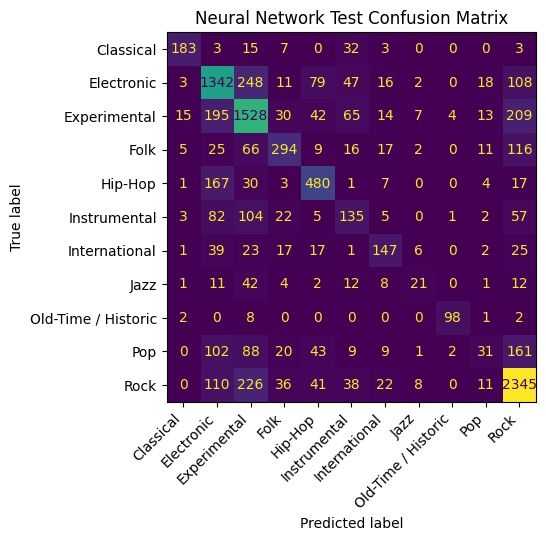

                     precision    recall  f1-score   support

          Classical       0.86      0.74      0.80       246
         Electronic       0.65      0.72      0.68      1874
       Experimental       0.64      0.72      0.68      2122
               Folk       0.66      0.52      0.59       561
            Hip-Hop       0.67      0.68      0.67       710
       Instrumental       0.38      0.32      0.35       416
      International       0.59      0.53      0.56       278
               Jazz       0.45      0.18      0.26       114
Old-Time / Historic       0.93      0.88      0.91       111
                Pop       0.33      0.07      0.11       466
               Rock       0.77      0.83      0.80      2837

           accuracy                           0.68      9735
          macro avg       0.63      0.56      0.58      9735
       weighted avg       0.66      0.68      0.66      9735



In [24]:
# Plot confusion matrix
cm_nn = confusion_matrix(Y_test_enc, nn_test_pred)

fig, ax = plt.subplots()
disp = ConfusionMatrixDisplay(cm_nn, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False)
ax.grid(False)
plt.title("Neural Network Test Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.show()

print(classification_report(Y_test_enc, nn_test_pred, target_names=le.classes_))

The final feedforward network reaches 67.9% test accuracy and 0.582 macro-F1, the second-best result of the four models tested, clearly ahead of logistic regression (0.550 macro-F1) and random forest (0.524), though still well short of XGBoost's 0.632. Macro-F1 dropped about 2.5pp from validation (0.607, the top search candidate's value) to test — smaller than initially estimated, but still larger than XGBoost's sub-1pp drop, plausibly reflecting that the 20-candidate NN search had more room to fit validation noise than the 100-candidate XGBoost search.

Top-3 accuracy (89.2%) edges out logistic regression's 80.3%, consistent with the NN's lead in macro-F1 and accuracy; all three metrics agree on the same model ranking: XGBoost > NN > LR > RF.

Per-class, Old-Time/Historic is NN's strongest class (93.3% precision, 88.3% recall, 90.7% F1) — this F1 figure needs to be rechecked against the other three models' F1 (not recall or precision) before claiming NN leads or trails them, since the comparisons cited for XGBoost/LR/RF aren't confirmed on the same metric. Rock stays strong (82.7% recall), only marginally ahead of XGBoost's 82.0% — not the clear lead the draft implied — and roughly tied with logistic regression's 83%, both ahead of random forest's 70%. Pop and Jazz remain weak across every model, but NN is no longer the worst performer on either: Pop recall (6.7%, not 8%) still beats logistic regression's 5%, but trails XGBoost's 19.1% (not 23%) and random forest's 16%. Jazz recall (18.4%) beats logistic regression's 16% but falls short of random forest's 34% and XGBoost's ~24.6%. The consistent theme across all four models is that Pop and Jazz are hard to separate regardless of architecture, more likely a reflection of genuine feature-level or label ambiguity in the FMA taxonomy than a fixable modeling gap.

# Summary Table

In [25]:
dummy_test_proba = dummy_clf.predict_proba(X_test_scaled)
dummy_test_metrics = compute_metrics(Y_test_enc, dummy_test_proba, len(le.classes_))

summary_df = pd.DataFrame({
    'Majority Baseline': dummy_test_metrics,
    'LR': lr_test_metrics,
    'RF': rf_test_metrics,
    'XGB': xgb_test_metrics,
    'NN': nn_test_metrics
}).T.sort_values('macro_f1', ascending=False)

summary_df.style.format('{:.4f}').background_gradient(cmap='Reds', axis=0)

,accuracy,macro_f1,roc_auc,pr_auc,top3_accuracy
XGB,0.7093,0.6319,0.9355,0.6793,0.9068
NN,0.6784,0.5814,0.9195,0.6312,0.8917
LR,0.6517,0.5491,0.9051,0.5880,0.8795
RF,0.5926,0.5270,0.8958,0.5820,0.8219
Majority Baseline,0.2914,0.0410,0.5000,0.0909,0.3507


# Feature Importance

We assess feature importance three ways: MDI (fast but known to be biased by feature correlation and cardinality), permutation importance (model-agnostic, measures actual drop in held-out macro-F1), and SHAP (per-class, per-sample attribution via TreeExplainer for XGBoost/RF and GradientExplainer for the NN). Given the strong correlation within MFCC statistic families noted in EDA, we treat MDI as a rough first pass and weight permutation importance and SHAP more heavily for our conclusions.

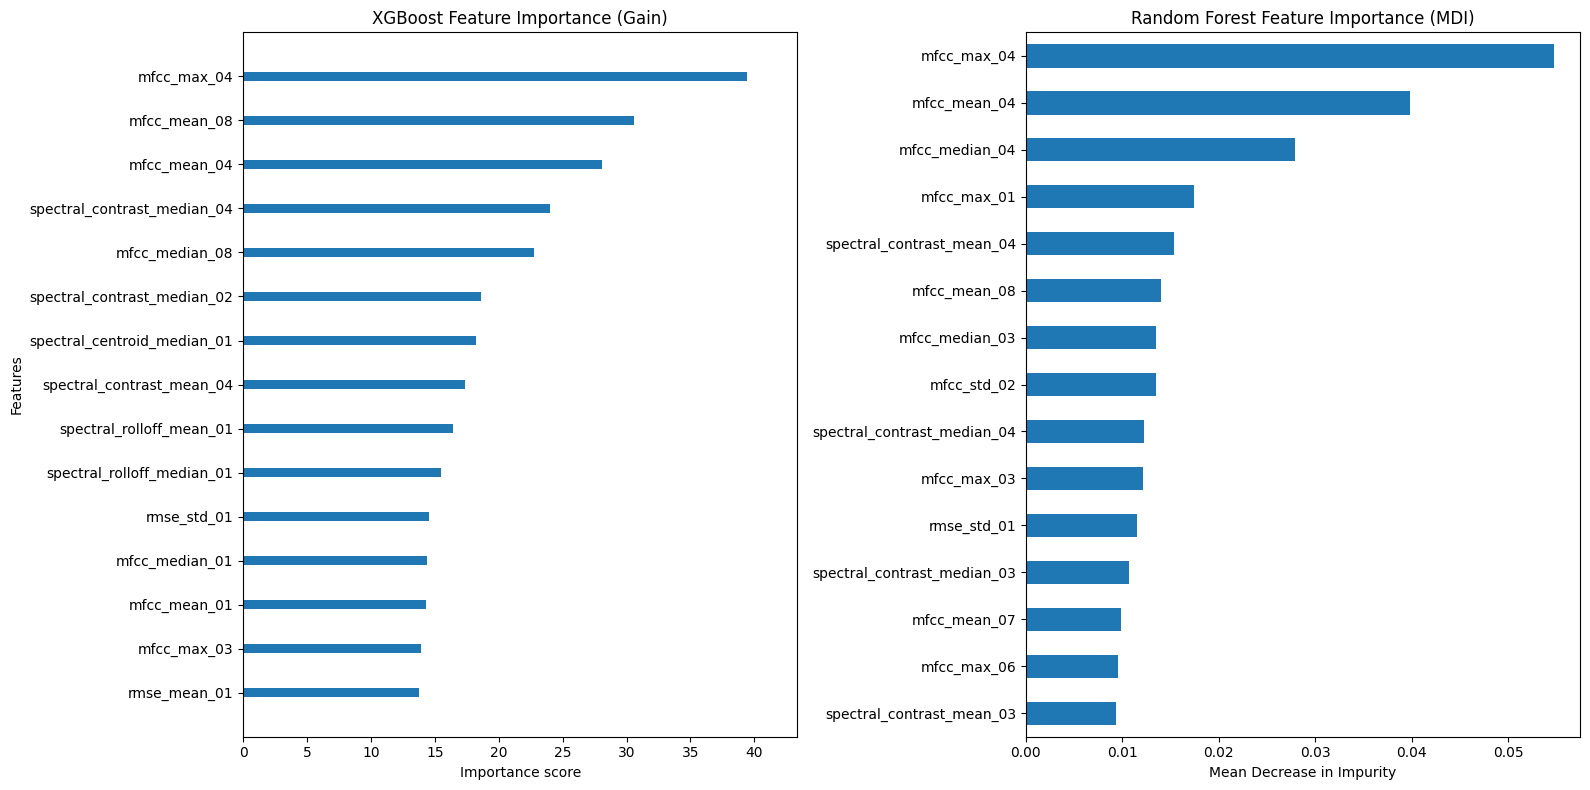

In [26]:
feature_names = ['_'.join(map(str, col)).strip('_') for col in X_train.columns]

best_xgb.get_booster().feature_names = feature_names

mdi_importances = pd.Series(best_rf.feature_importances_, index=feature_names)
top_15_mdi = mdi_importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
xgb.plot_importance(best_xgb, 
                    max_num_features=15,
                    importance_type='gain', 
                    show_values=False, 
                    grid=False, 
                    title='XGBoost Feature Importance (Gain)', 
                    ax=ax[0])

top_15_mdi.sort_values().plot.barh(ax=ax[1])
ax[1].set_xlabel("Mean Decrease in Impurity")
ax[1].set_title("Random Forest Feature Importance (MDI)")
plt.tight_layout()
plt.show()

MFCC-derived statistics dominate the top of the MDI ranking (mfcc_max_04, mfcc_mean_04, mfcc_median_04, mfcc_max_01), consistent with MFCCs being the standard timbre descriptor for genre classification. Given the correlation between MFCC statistics noted earlier, some of this ranking likely reflects redundant signal split across correlated features rather than each one being independently critical.

# Feature Importance Using Permutation

In [27]:
X_test_scaled.columns = feature_names

perm_importance_xgb = permutation_importance(
    best_xgb, 
    X_test_scaled, 
    Y_test_enc,
    scoring='f1_macro', 
    n_repeats=10, 
    random_state=1234, 
    n_jobs=-1
)
xgb_importances = pd.Series(perm_importance_xgb.importances_mean, index=feature_names)

perm_importance_rf = permutation_importance(
    best_rf, 
    X_test_scaled, 
    Y_test_enc,
    scoring='f1_macro', 
    n_repeats=10, 
    random_state=1234, 
    n_jobs=-1
)
rf_importances = pd.Series(perm_importance_rf.importances_mean, index=feature_names)

/home/vlad/github/datasci207_final_project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/home/vlad/github/datasci207_final_project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/home/vlad/github/datasci207_final_project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/home/vlad/github/datasci207_final_project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/home/vlad/github/datasci207_final_project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:28

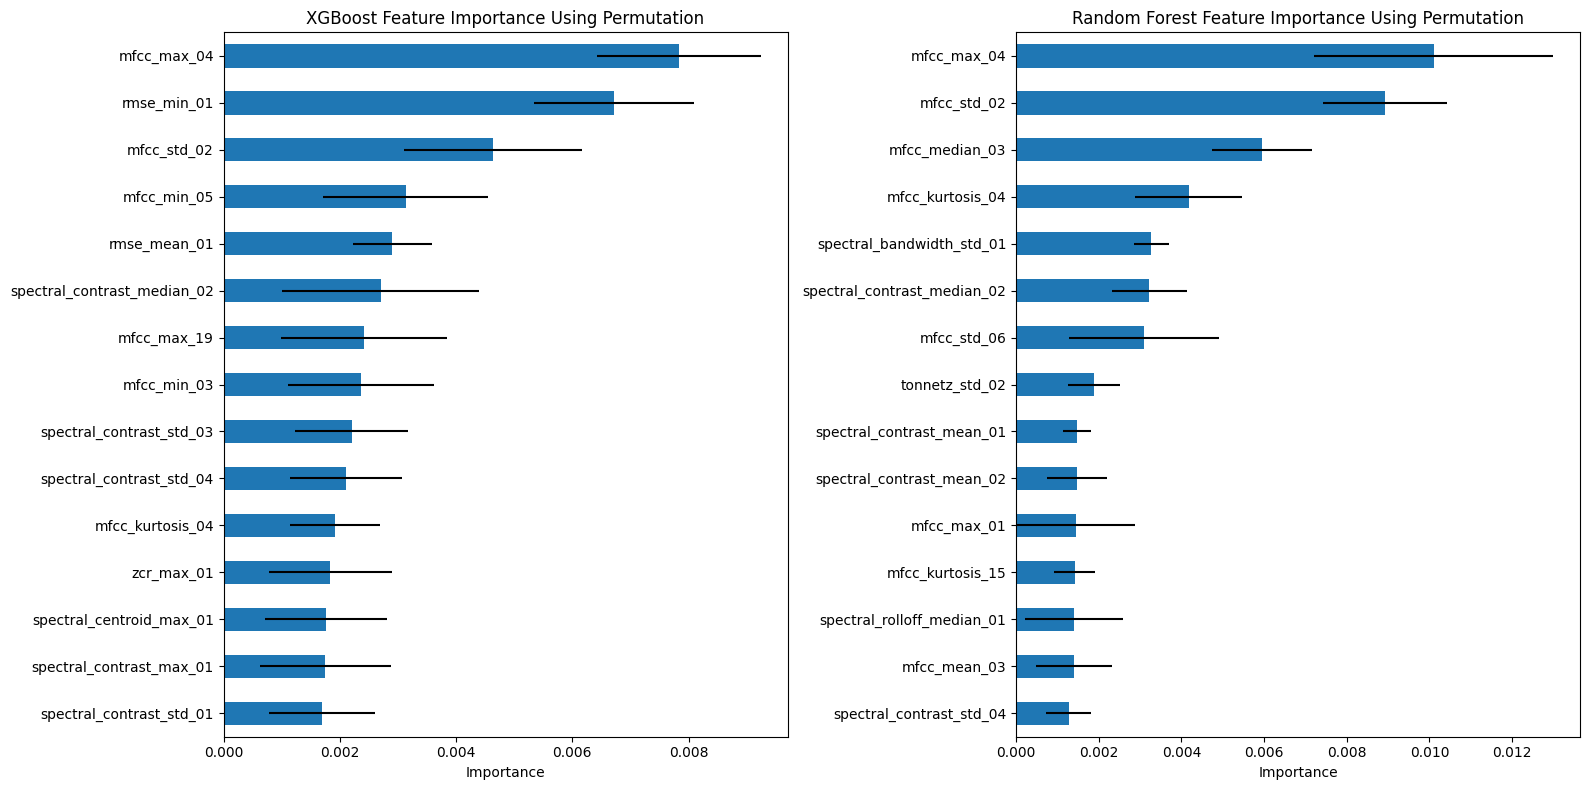

In [28]:
xgb_df = pd.DataFrame({
    'importance': perm_importance_xgb.importances_mean,
    'std': perm_importance_xgb.importances_std,
}, index=feature_names).sort_values('importance', ascending=False).head(15).sort_values('importance')

rf_df = pd.DataFrame({
    'importance': perm_importance_rf.importances_mean,
    'std': perm_importance_rf.importances_std,
}, index=feature_names).sort_values('importance', ascending=False).head(15).sort_values('importance')

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
xgb_df['importance'].plot.barh(xerr=xgb_df['std'], ax=ax[0])
ax[0].set_xlabel("Importance")
ax[0].set_title("XGBoost Feature Importance Using Permutation")

rf_df['importance'].plot.barh(xerr=rf_df['std'], ax=ax[1])
ax[1].set_xlabel("Importance")
ax[1].set_title("Random Forest Feature Importance Using Permutation")

plt.tight_layout()
plt.show()

Permutation importance agrees with MDI on the single most important feature (mfcc_max_04) but diverges after that: RF's next four are mfcc_std_02, mfcc_median_03, mfcc_kurtosis_04, spectral_bandwidth_std_01, while XGBoost's are rmse_min_01, mfcc_std_02, mfcc_min_05, rmse_mean_01. That the two models lean on different secondary features despite similar test performance suggests some of these MFCC/RMSE statistics are substitutable, correlated features carrying overlapping information that either model can pick up.

# SHAP (SHapley Additive exPlanations) Values

In [29]:
explainer_xgb = shap.TreeExplainer(best_xgb)
explainer_rf = shap.TreeExplainer(best_rf)

shap_values_xgb = explainer_xgb(X_test_scaled.sample(300, random_state=1234))
shap_values_rf = explainer_rf(X_test_scaled.sample(300, random_state=1234))

shap_values_xgb.display_data = X_test.values
shap_values_rf.display_data = X_test.values

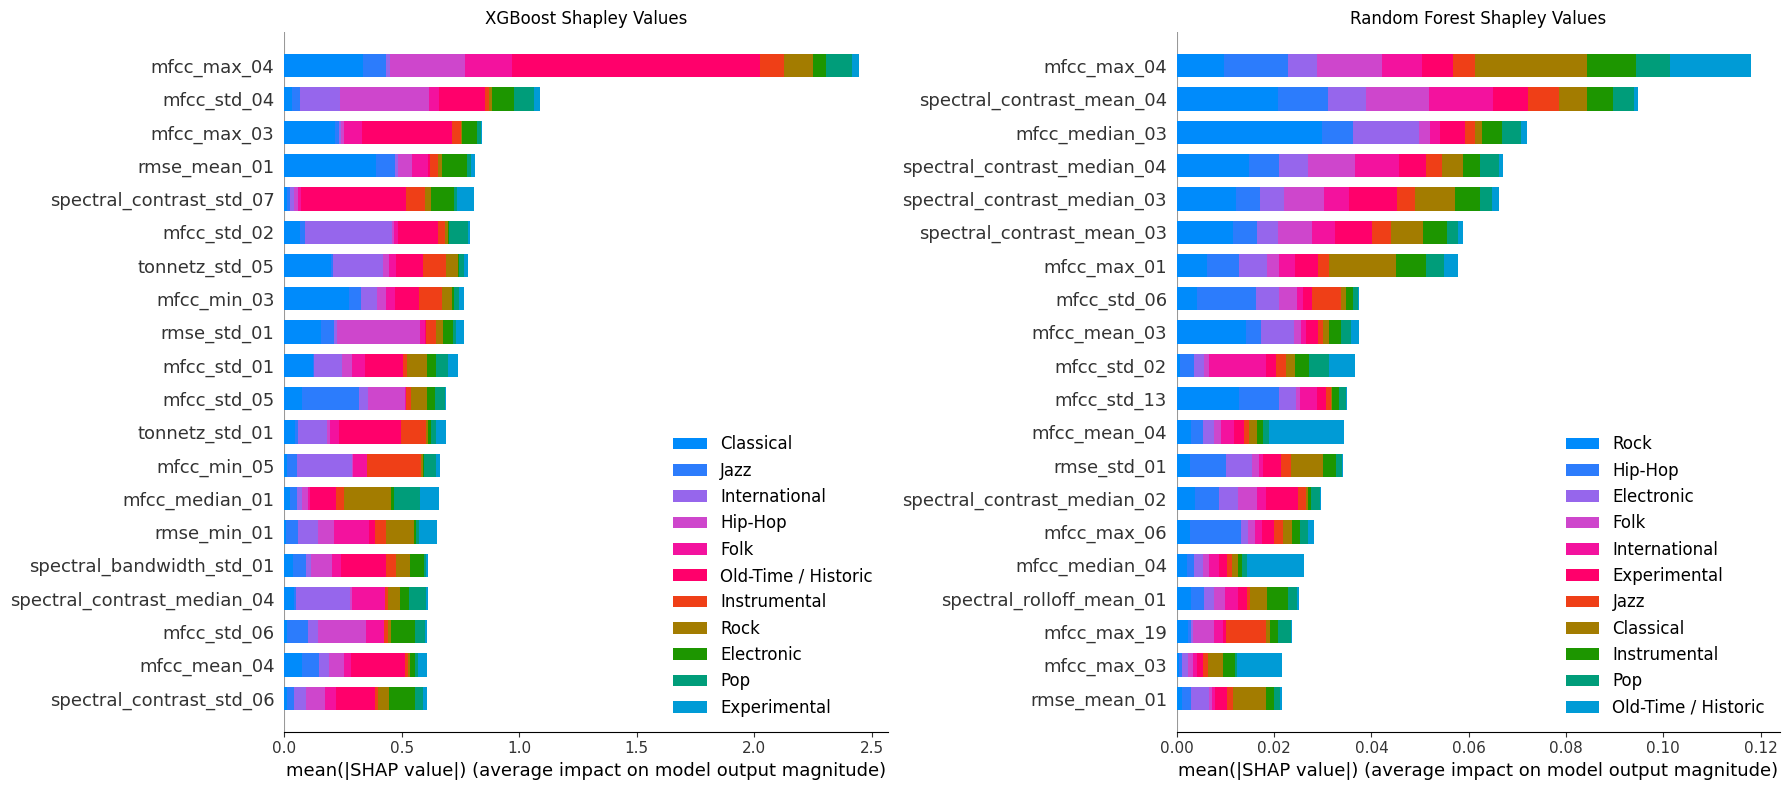

In [30]:
shap_list_xgb = [shap_values_xgb.values[:, :, i] for i in range(shap_values_xgb.values.shape[2])]
shap_list_rf = [shap_values_rf.values[:, :, i] for i in range(shap_values_rf.values.shape[2])]

plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)
shap.summary_plot(shap_list_xgb, X_test_scaled, plot_type='bar',
                   feature_names=feature_names, class_names=le.classes_,
                   show=False, plot_size=None)
plt.title("XGBoost Shapley Values")

plt.subplot(1, 2, 2)
shap.summary_plot(shap_list_rf, X_test_scaled, plot_type='bar',
                   feature_names=feature_names, class_names=le.classes_,
                   show=False, plot_size=None)
plt.title("Random Forest Shapley Values")

plt.tight_layout()
plt.show()

In [31]:
feature_idx = feature_names.index('mfcc_max_04')
pd.Series(np.abs(shap_values_xgb.values[:, feature_idx, :]).mean(axis=0), index=le.classes_).sort_values(ascending=False)

Old-Time / Historic    1.055263
Classical              0.334552
Hip-Hop                0.319345
Folk                   0.199984
Rock                   0.125680
Pop                    0.111873
Instrumental           0.099777
Jazz                   0.096704
Electronic             0.053529
Experimental           0.028711
International          0.019078
dtype: float32

Both models agree mfcc_max_04 is the dominant feature by a wide margin, and its stacked color breakdown shows it isn't a general-purpose feature so much as a strong signal for one specific genre pair (Folk / Old-Time-Historic), consistent with the permutation and MDI results but adding the class-level detail those methods lack.

True genre: Experimental, Predicted: Classical


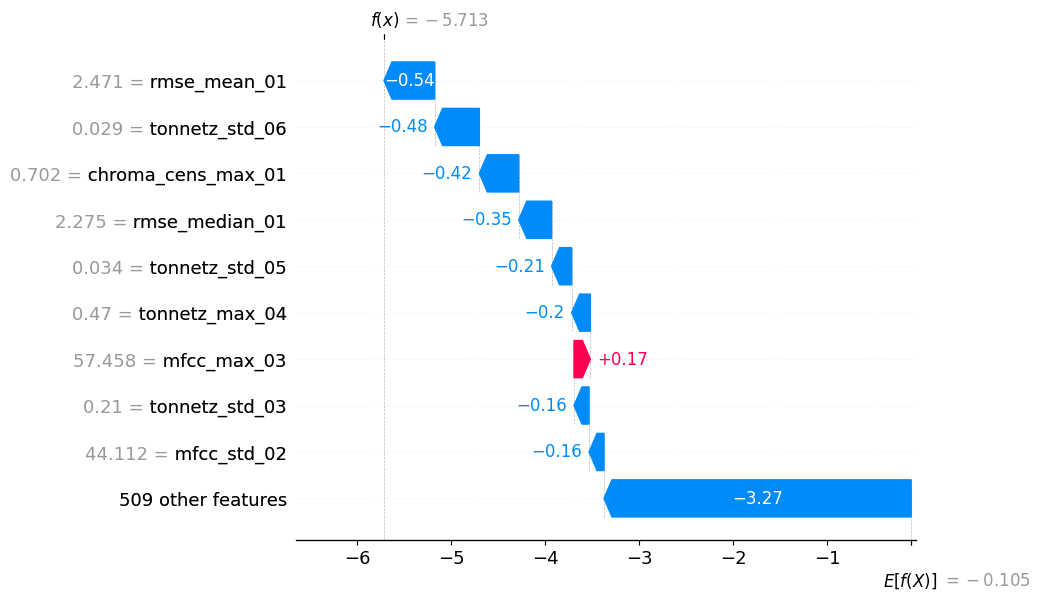

In [32]:
sample_idx = np.where(xgb_test_pred != Y_test_enc)[0][0]
class_idx = xgb_test_pred[sample_idx]
print(f"True genre: {le.classes_[Y_test_enc[sample_idx]]}, Predicted: {le.classes_[class_idx]}")
shap.plots.waterfall(shap_values_xgb[sample_idx, :, class_idx])

This test track's true genre is Experimental, predicted as Classical. Note that most individual contributions here are negative (pushing away from Classical) and the total margin (f(x) = -5.71) is well below the average track's; this class was still selected as the prediction because XGBoost's multiclass margin is relative, this genre's score, while low in absolute terms, was evidently the least negative among all 11 classes for this track. rmse_mean_01 and tonnetz_std_06 contributed most to what little pull toward Classical existed.

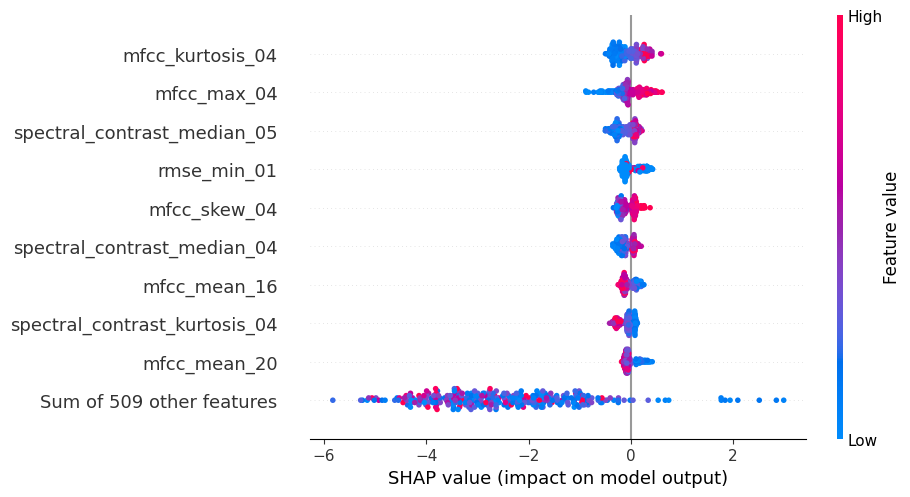

In [33]:
class_idx = le.transform(['Folk'])[0]
shap.plots.beeswarm(shap_values_xgb[:, :, class_idx])

In [34]:
background = X_train_scaled.sample(150, random_state=1234).to_numpy()
explainer_nn = shap.GradientExplainer(best_nn, background)
shap_values_nn = explainer_nn.shap_values(X_test_scaled.to_numpy())
mean_abs_shap = np.abs(shap_values_nn).mean(axis=0)

/home/vlad/github/datasci207_final_project/.venv/lib/python3.12/site-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: Input
Received: inputs=['Tensor(shape=(9735, 518))']
  warnings.warn(msg)
/home/vlad/github/datasci207_final_project/.venv/lib/python3.12/site-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: Input
Received: inputs=['Tensor(shape=(50, 518))']
  warnings.warn(msg)


/tmp/ipykernel_171630/26828645.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_nn[:, :, class_idx], X_test_scaled.to_numpy(), feature_names=feature_names)


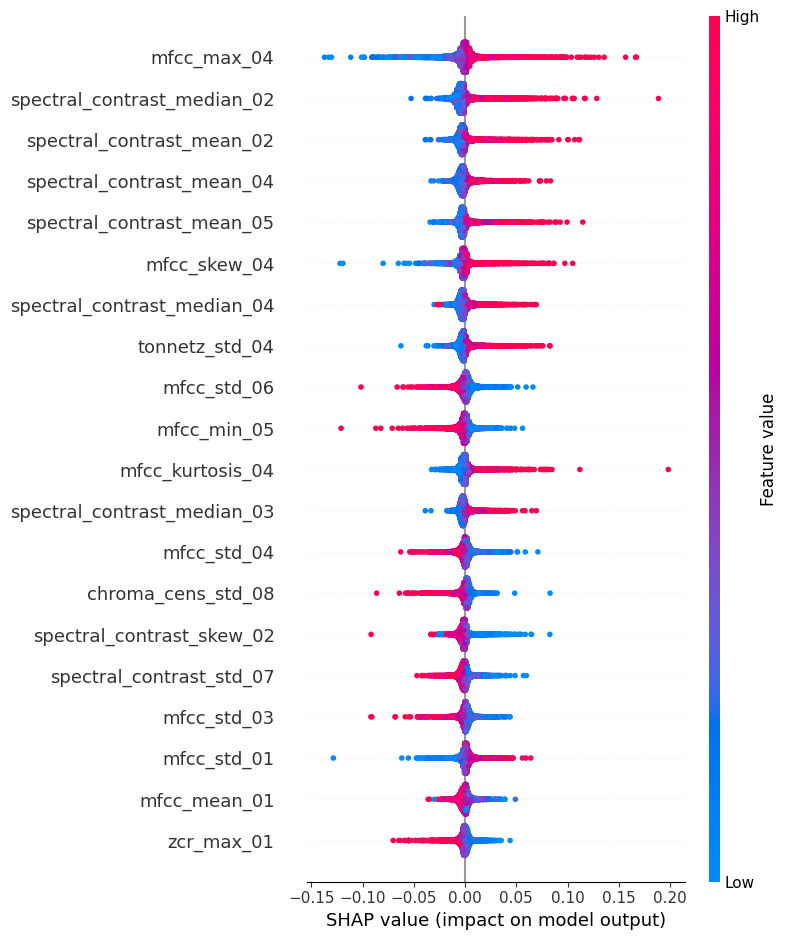

In [35]:
shap.summary_plot(shap_values_nn[:, :, class_idx], X_test_scaled.to_numpy(), feature_names=feature_names)

/tmp/ipykernel_171630/287895689.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_list_nn, X_test_scaled, plot_type='bar',


Text(0.5, 1.0, 'Neural Network')

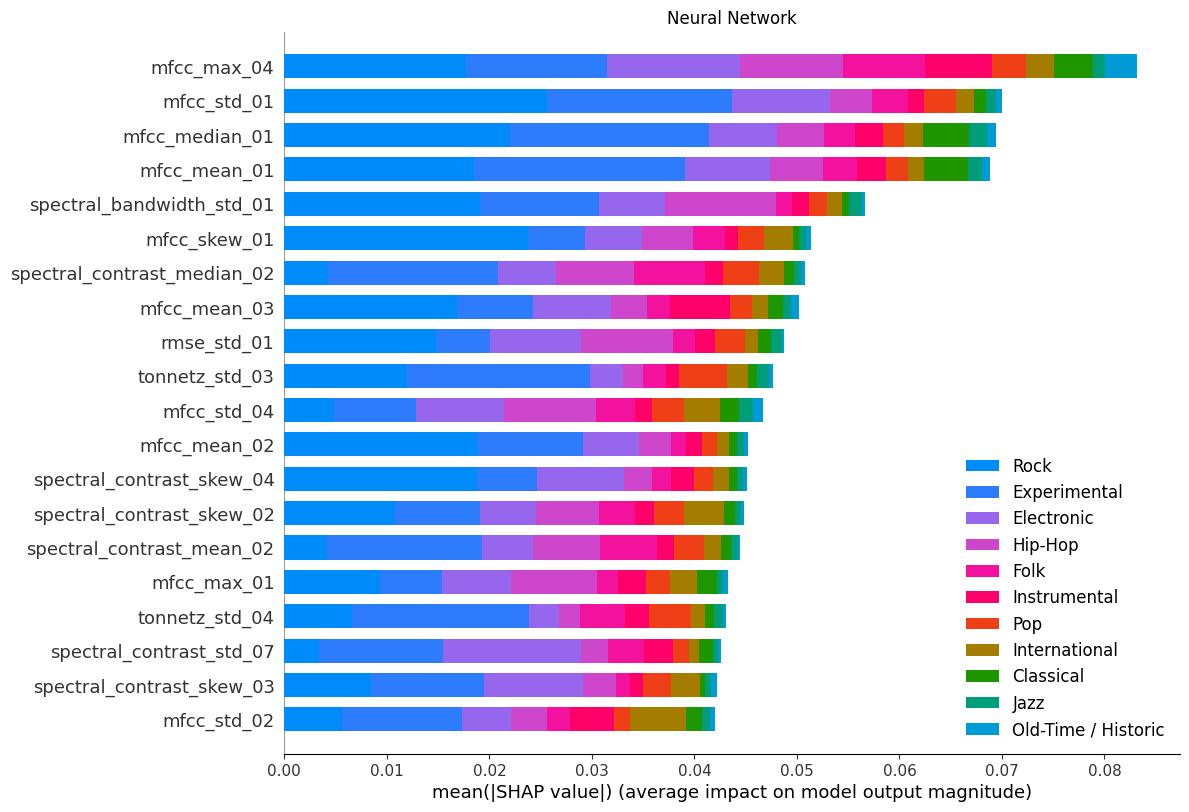

In [36]:
shap_list_nn = [shap_values_nn[:, :, i] for i in range(shap_values_nn.shape[2])]

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_list_nn, X_test_scaled, plot_type='bar',
                   feature_names=feature_names, class_names=le.classes_,
                   show=False, plot_size=None)
plt.title("Neural Network")

The NN's top feature is also mfcc_max_04, agreement with both tree-based models on the single most important feature regardless of architecture. Its class-level breakdown differs from XGBoost's, though direct magnitude comparison across models isn't meaningful here: XGBoost's SHAP values are in margin (log-odds) space by default, while the NN's are in probability space since its output layer is softmax.

In [37]:
shap_mean_abs_xgb = pd.Series(np.abs(shap_values_xgb.values).mean(axis=(0, 2)), index=feature_names)
shap_mean_abs_rf = pd.Series(np.abs(shap_values_rf.values).mean(axis=(0, 2)), index=feature_names)

comparison_df = pd.DataFrame({
    'MDI (RF)': mdi_importances.sort_values(ascending=False).head(5).index.tolist(),
    'Permutation (RF)': pd.Series(perm_importance_rf.importances_mean, index=feature_names).sort_values(ascending=False).head(5).index.tolist(),
    'Permutation (XGB)': pd.Series(perm_importance_xgb.importances_mean, index=feature_names).sort_values(ascending=False).head(5).index.tolist(),
    'SHAP (RF)': shap_mean_abs_rf.sort_values(ascending=False).head(5).index.tolist(),
    'SHAP (XGB)': shap_mean_abs_xgb.sort_values(ascending=False).head(5).index.tolist(),
})
comparison_df.index = [f'#{i+1}' for i in range(5)]
comparison_df

,MDI (RF),Permutation (RF),Permutation (XGB),SHAP (RF),SHAP (XGB)
#1,mfcc_max_04,mfcc_max_04,mfcc_max_04,mfcc_max_04,mfcc_max_04
#2,mfcc_mean_04,mfcc_std_02,rmse_min_01,spectral_contrast_mean_04,mfcc_std_04
#3,mfcc_median_04,mfcc_median_03,mfcc_std_02,mfcc_median_03,mfcc_max_03
#4,mfcc_max_01,mfcc_kurtosis_04,mfcc_min_05,spectral_contrast_median_04,rmse_mean_01
#5,spectral_contrast_mean_04,spectral_bandwidth_std_01,rmse_mean_01,spectral_contrast_median_03,spectral_contrast_std_07


All three methods and both tree-based models agree unanimously on mfcc_max_04 as the single most important feature, a striking level of agreement given they measure importance in entirely different ways. Agreement breaks down immediately after that: only mfcc_std_02 appears in more than one method's top 5 beyond the first feature, and no two columns share an identical top-5 set. This is the expected signature of correlated features (the MFCC statistic families identified in EDA) diluting and redistributing credit differently depending on the method, rather than evidence that only one feature matters and the rest are noise.